<a href="https://colab.research.google.com/github/PedroJRod/Projeto-de-Identifica-o-de-Anomalias-em-Despesas---Prefeitura/blob/main/notebooks/Projeto_Isolation_Forest_com_Empenhos_Credenciamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação das bibliotecas

In [1]:
pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 6.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from unidecode import unidecode

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder

import math

# Pacotes gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de manipulação de textos
import re
import string

## Importação da base de dados

In [3]:
df = pd.read_excel('RConferencia_Despesa_Empenho_excel_30_09_2024_09_48_25.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
df.head(10)

,ESTADO DE MATO GROSSO,"Segunda-feira, 30 de Setembro de 2024",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,PREFEITURA MUNICIPAL DE CAMPO VERDE MT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"PRACA DOS TRES PODERES, Nº 3, CAMPO REAL II, C...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CONFERÊNCIA DA DESPESA - EMPENHO 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,No período de 01/01/2024 até 31/12/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NÚM.EMP/ANO,TIPO,DATA,DOTAÇÃO,SUBELEMENTO DE DESPESA,LICITAÇÃO,MODALIDADE DA LICITAÇÃO,CREDOR,VALOR
9,00000005914/2024,2,02/04/2024,0187 - 05001123610013200223390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2035.80


## Preparação dos Dados

In [5]:
df.columns = df.iloc[8]  # Definindo a primeira linha como cabeçalho
df = df.reset_index(drop=True)

def to_snake_case(column_name):
    column_name = unidecode(column_name)  # Remove acentos
    column_name = column_name.strip().lower().replace(" ", "_").replace("-", "_")
    return ''.join(e for e in column_name if e.isalnum() or e == '_')

# Renomeando as colunas usando a função to_snake_case
df.columns = [to_snake_case(col) for col in df.columns]

In [6]:
df = df.iloc[9:]  # Removendo as linhas iniciais
df = df.iloc[:-2]  # Removendo as linhas finais

In [7]:
df['numempano'].fillna(method='ffill', inplace=True)  # Preenchendo os valores nulos com o valor da linha anterior

<ipython-input-7-a7ce7ba18ab6>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['numempano'].fillna(method='ffill', inplace=True)


In [8]:
df = df.dropna(subset=['tipo'])  # Removendo as linhas com valores nulos na coluna 'tipo'

In [9]:
df = df.reset_index(drop=True)

In [10]:
# Filtrando as linhas onde a coluna 'numempano' é diferente de "DESCRIÇÃO:"
df_empenhos = df[~df['numempano'].isin(["DESCRIÇÃO:"])]

In [11]:
df_empenhos = df_empenhos.reset_index(drop=True)
df_empenhos.head(5)

,numempano,tipo,data,dotacao,subelemento_de_despesa,licitacao,modalidade_da_licitacao,credor,valor
0,00000005914/2024,2,02/04/2024,0187 - 05001123610013200223390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2035.80
1,00000005926/2024,2,02/04/2024,1428 - 08001154520018201843390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,2998.08
2,00000005962/2024,2,03/04/2024,0840 - 09001278130030201003390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2635.24
3,00000005969/2024,2,03/04/2024,0196 - 05001123650011201733390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2693.52
4,00000005970/2024,2,03/04/2024,0187 - 05001123610013200223390390000,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,1941.84


### Tratamento das Descrições dos Empenhos - Concatenação dos textos relacionados a mesma descrição

In [12]:
# Lista para armazenar resultados
resultados = []
concat_str = ''

# Percorrer as linhas do DataFrame
for index, row in df.iterrows():
    if row['numempano'] == 'DESCRIÇÃO:':
        # Continuar a concatenação
        concat_str += str(row['tipo']) + ' '
    elif row['numempano'] != 'DESCRIÇÃO:':
        # Finalizar concatenação e adicionar ao resultado
        if concat_str:
            resultados.append(concat_str.strip())
        concat_str = ''

# Se ainda houver algo concatenado (última linha não foi ORDEM DE CONSUMO:)
if concat_str:
    resultados.append(concat_str.strip())

# Criar novo DataFrame com os resultados
df_descricoes = pd.DataFrame(resultados, columns=['descricao'])

# Exibir o resultado
df_descricoes.head(5)

,descricao
0,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...
1,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...
2,VALOR QUE SE EMPENHA PARA A PRESTAÇÃO DE SERVI...
3,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE P...
4,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...


In [13]:
df_descricoes.shape

(230, 1)

### Tratamento do Atributo Código de Dotação - separação em Órgão, Elemento da despesa e Classificação Funcional_programática

In [14]:
df_despesas = pd.concat([df_empenhos, df_descricoes], axis=1)
df_despesas[['reduzido','dotacao']] = df_despesas['dotacao'].str.split(' - ', expand=True)

# Converter a coluna 'data' para o tipo datetime
df_despesas['data'] = pd.to_datetime(df_despesas['data'], format='%d/%m/%Y')

# Extrair componentes da data
df_despesas['mes'] = df_despesas['data'].dt.month

df_despesas['valor'] = pd.to_numeric(df_despesas['valor'])

df_despesas['elemento_despesa'] = df_despesas['dotacao'].str[-10:]

df_despesas['dotacao'] = df_despesas['dotacao'].str[:-10]

df_despesas['orgao_unidade'] = df_despesas['dotacao'].str[:2]

df_despesas['dotacao'] = df_despesas['dotacao'].str[5:]

df_despesas = df_despesas.rename(columns={'dotacao': 'funcional_programatica'})

df_despesas.head(5)

,numempano,tipo,data,funcional_programatica,subelemento_de_despesa,licitacao,modalidade_da_licitacao,credor,valor,descricao,reduzido,mes,elemento_despesa,orgao_unidade
0,00000005914/2024,2,2024-04-02,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2035.80,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05
1,00000005926/2024,2,2024-04-02,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,2998.08,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...,1428,4,3390390000,08
2,00000005962/2024,2,2024-04-03,27813003020100,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2635.24,VALOR QUE SE EMPENHA PARA A PRESTAÇÃO DE SERVI...,0840,4,3390390000,09
3,00000005969/2024,2,2024-04-03,12365001120173,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2693.52,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE P...,0196,4,3390390000,05
4,00000005970/2024,2,2024-04-03,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,1941.84,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05


In [15]:
df_despesas.shape

(230, 14)

In [16]:
# Seleção das variáveis para NLP
df_nlp = df_despesas[['descricao']].copy()
df_nlp

,descricao
0,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...
1,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...
2,VALOR QUE SE EMPENHA PARA A PRESTAÇÃO DE SERVI...
3,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE P...
4,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...
...,...
225,VALOR QUE SE EMPENHA PARA AQUISIÇÃO DE VALOR ...
226,VALOR QUE SE EMPENHA PARA HORAS DE CREDENCIAM...
227,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE P...
228,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...


### Tratamento dos textos do atributo Descrição

In [17]:
pip install -U spacy

In [18]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 17.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
import spacy
modelo_spacy = spacy.load('pt_core_news_sm')

In [20]:
#modelo_spacy.Defaults.stop_words.clear()

In [21]:
modelo_spacy.Defaults.stop_words

{'a',
 'acerca',
 'ademais',
 'adeus',
 'agora',
 'ainda',
 'algo',
 'algumas',
 'alguns',
 'ali',
 'além',
 'ambas',
 'ambos',
 'antes',
 'ao',
 'aos',
 'apenas',
 'apoia',
 'apoio',
 'apontar',
 'após',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aqui',
 'aquilo',
 'as',
 'assim',
 'através',
 'atrás',
 'até',
 'aí',
 'baixo',
 'bastante',
 'bem',
 'boa',
 'bom',
 'breve',
 'cada',
 'caminho',
 'catorze',
 'cedo',
 'cento',
 'certamente',
 'certeza',
 'cima',
 'cinco',
 'coisa',
 'com',
 'como',
 'comprida',
 'comprido',
 'conhecida',
 'conhecido',
 'conselho',
 'contra',
 'contudo',
 'corrente',
 'cuja',
 'cujo',
 'custa',
 'cá',
 'da',
 'daquela',
 'daquele',
 'dar',
 'das',
 'de',
 'debaixo',
 'demais',
 'dentro',
 'depois',
 'des',
 'desde',
 'dessa',
 'desse',
 'desta',
 'deste',
 'deve',
 'devem',
 'deverá',
 'dez',
 'dezanove',
 'dezasseis',
 'dezassete',
 'dezoito',
 'diante',
 'direita',
 'disso',
 'diz',
 'dizem',
 'dizer',
 'do',
 'dois',
 'dos',
 'doze',
 'duas',
 'dá

In [22]:
def preproc_nlp(texto, modelo_spacy=modelo_spacy):

    # Aplicação do modelo no texto original
    texto_spacy = list(modelo_spacy(texto))

    # Lista de tokens após preparação
    texto_result = list()

    for t in texto_spacy:
        # Remoção de pontuação
        if t.is_punct:
            continue
        # Remoção de números
        if t.is_digit:
            continue
        # Remoção de espaços extras
        if t.is_space:
            continue
        # Remoção de stopwords
        if t.is_stop:
            continue
        # Conversão para minúsculas e lematização
        texto_result.append(t.lemma_.lower())

    texto_result = ' '.join(texto_result)

    return texto_result

In [23]:
df_nlp['descricao_clean'] = df_nlp['descricao'].apply(preproc_nlp)

In [24]:
from wordcloud import WordCloud

In [25]:
# Função para geração da WordCloud
def plot_wordcloud(wc):
    plt.figure(figsize=(20,10))
    plt.imshow(wc)
    plt.axis("off")

In [26]:
wc_texto = WordCloud(width = 1000, height = 500)\
    .generate_from_text(' '.join(df_nlp['descricao_clean'].to_list()))

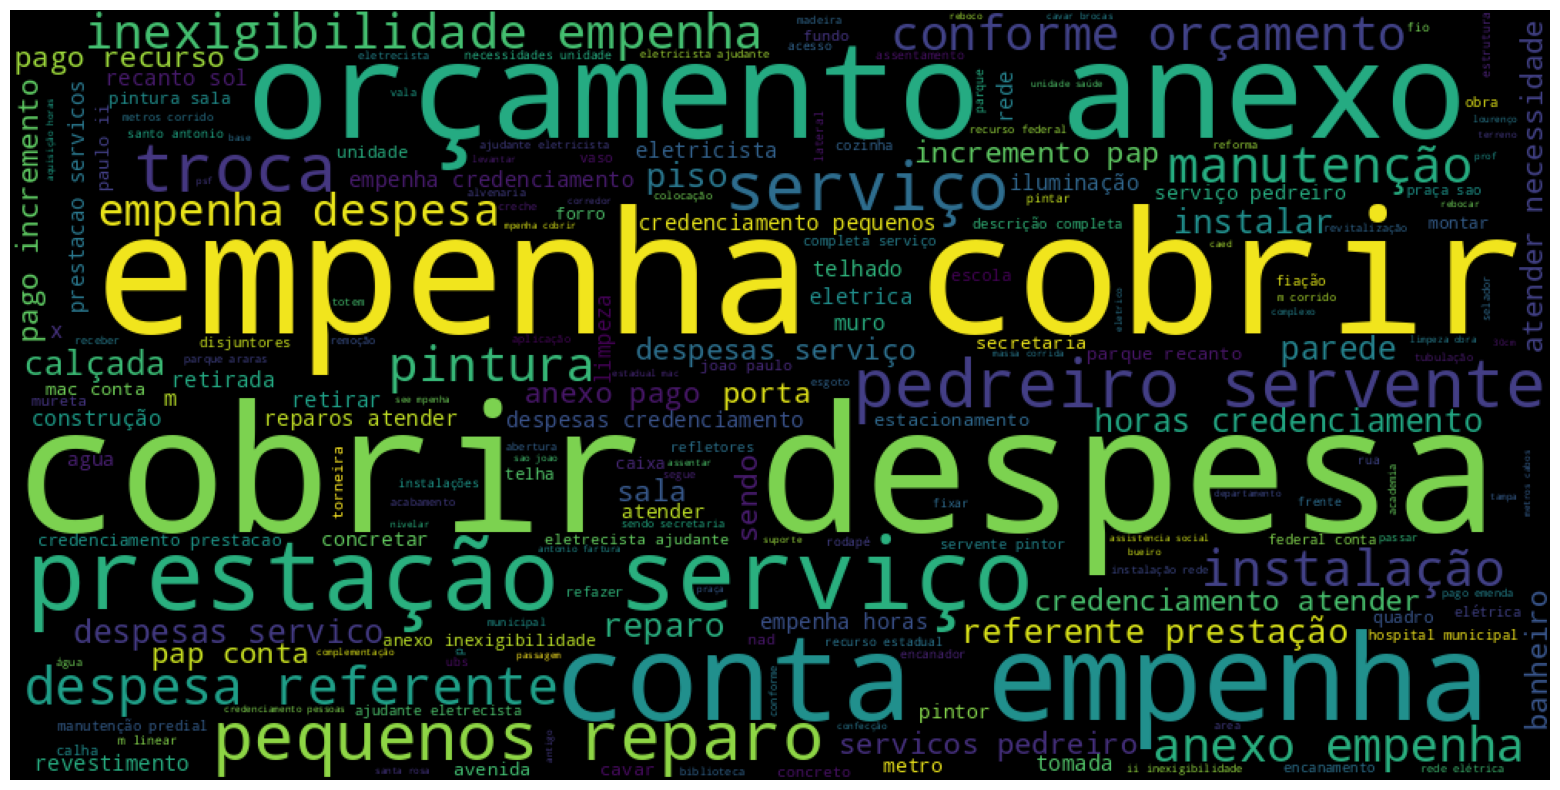

In [27]:
plot_wordcloud(wc_texto)

In [28]:
# Adição de tokens na lista de stopwords
modelo_spacy.Defaults.stop_words |= {"sendo","instalar","pedreiro","servente","despesa","despesas","empenha","orçamento", "anexo","prestação","prestacao","referente","serviço","servicos","pequenos","reparo","conforme","atender","necessidade","inexigibilidade","conta","credenciamento","manutenção"}

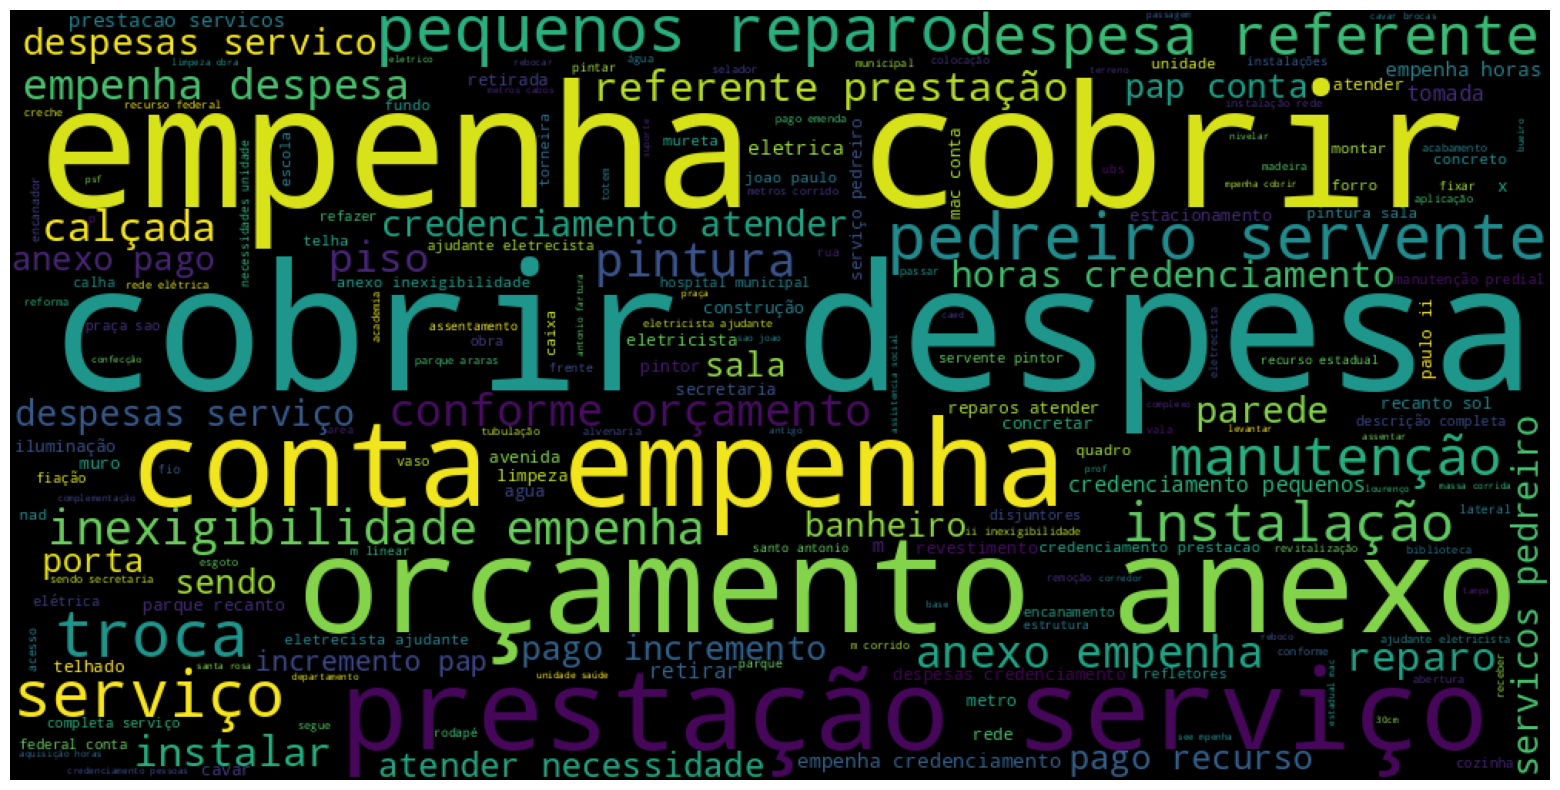

In [29]:
df_nlp['descricao_clean'] = df_nlp['descricao'].apply(preproc_nlp)

wc_texto = WordCloud(width = 1000, height = 500)\
    .generate_from_text(' '.join(df_nlp['descricao_clean'].to_list()))

plot_wordcloud(wc_texto)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidfvec = TfidfVectorizer(ngram_range=(1,2))
tfidfvec_data = tfidfvec.fit_transform(df_nlp['descricao_clean'])

In [32]:
tfidfvec.vocabulary_

{'empenha': 1397,
 'despesa': 1203,
 'referente': 3149,
 'prestação': 2935,
 'serviço': 3596,
 'manutenção': 2257,
 'escola': 1475,
 'paraiso': 2609,
 'sendo': 3522,
 'assentar': 447,
 'ceramica': 800,
 'trocar': 3900,
 'valvula': 3992,
 'registro': 3185,
 'banheiro': 557,
 'parede': 2617,
 'torneiras': 3825,
 'cifões': 829,
 'fixar': 1697,
 'porta': 2854,
 'instalar': 1946,
 'chuveiros': 819,
 'abrir': 225,
 'alçapão': 322,
 'forro': 1711,
 'conforme': 955,
 'orçamento': 2568,
 'anexo': 340,
 'empenha despesa': 1405,
 'despesa referente': 1205,
 'referente prestação': 3156,
 'prestação serviço': 2940,
 'serviço manutenção': 3617,
 'manutenção escola': 2268,
 'escola paraiso': 1479,
 'paraiso sendo': 2611,
 'sendo assentar': 3526,
 'assentar ceramica': 449,
 'ceramica trocar': 802,
 'trocar valvula': 3903,
 'valvula registro': 3993,
 'registro banheiro': 3187,
 'banheiro parede': 564,
 'parede torneiras': 2632,
 'torneiras cifões': 3826,
 'cifões fixar': 830,
 'fixar porta': 1703,
 'po

In [33]:
df_tfidf_desc = pd.DataFrame(data=tfidfvec_data.toarray(),
                        index=df_nlp.index,
                        columns=tfidfvec.get_feature_names_out())
df_tfidf_desc

,00,00 60cm,00 prof,00 profundidade,002,002 2024,01,01 02,01x01,01x01 inexigibilidade,...,água anexo,água comunidade,água instalação,água maquinas,água piso,água preparo,água rede,água sabão,águas,águas orçamento
0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.116758,0.0,0.0,0.126937,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,0.000000,0.0,0.0,0.000000,0.121812,0.121812,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226,0.000000,0.0,0.0,0.000000,0.122300,0.122300,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
227,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
228,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
#Atualizar os nomes das colunas para refletir que são representações TF-IDF
df_tfidf_desc.columns = [f'descricao_tfidf_{i}' for i in range(df_tfidf_desc.shape[1])]

In [35]:
df_despesas.head(2)

,numempano,tipo,data,funcional_programatica,subelemento_de_despesa,licitacao,modalidade_da_licitacao,credor,valor,descricao,reduzido,mes,elemento_despesa,orgao_unidade
0,00000005914/2024,2,2024-04-02,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2035.80,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05
1,00000005926/2024,2,2024-04-02,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,2998.08,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...,1428,4,3390390000,08


### Padronização da Escala

In [36]:
le = LabelEncoder()
df_despesas['cnpj_encoded'] = le.fit_transform(df_despesas['credor'])
df_despesas['elemento_despesa_encoded'] = le.fit_transform(df_despesas['elemento_despesa'])
df_despesas['funcional_programatica_encoded'] = le.fit_transform(df_despesas['funcional_programatica'])

num = ['valor']
scaler = StandardScaler()
df_num = scaler.fit_transform(df_despesas[num])
df_num = pd.DataFrame(df_num, columns=num)

### Criação do Dataframe para utilização pelo algoratimo

In [37]:
df_modelo = pd.concat([df_despesas[['orgao_unidade','mes','cnpj_encoded','elemento_despesa_encoded','funcional_programatica_encoded']], df_num, df_tfidf_desc], axis=1)
df_modelo

,orgao_unidade,mes,cnpj_encoded,elemento_despesa_encoded,funcional_programatica_encoded,valor,descricao_tfidf_0,descricao_tfidf_1,descricao_tfidf_2,descricao_tfidf_3,...,descricao_tfidf_4067,descricao_tfidf_4068,descricao_tfidf_4069,descricao_tfidf_4070,descricao_tfidf_4071,descricao_tfidf_4072,descricao_tfidf_4073,descricao_tfidf_4074,descricao_tfidf_4075,descricao_tfidf_4076
0,05,4,6,0,16,-0.404251,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,08,4,15,0,33,-0.371721,0.116758,0.0,0.0,0.126937,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,09,4,6,0,47,-0.383987,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,05,4,6,0,22,-0.382017,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,05,4,6,0,16,-0.407428,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,08,9,9,0,33,-0.412781,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226,08,9,9,0,33,-0.372244,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
227,05,9,8,0,17,0.212248,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
228,07,9,6,0,36,-0.404726,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
#df_modelo = df_modelo.sample(frac=0.1, random_state=42)
#df_modelo.shape

### Divisão das bases em Treino e Teste

In [39]:
X_train, X_test = train_test_split(df_modelo, test_size=0.3, random_state=42)

### Treinamento do Modelo

In [40]:
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X_train)

IsolationForest(contamination=0.1, random_state=42)

In [41]:
isoforest_train_anomaly_score = model.decision_function(X_train)
isoforest_train_outlier_pred = model.predict(X_train)

isoforest_test_anomaly_score = model.decision_function(X_test)
isoforest_test_outlier_pred = model.predict(X_test)

In [42]:
# Construção do DataFrame de resultados
isoforest_train_outlier = pd.concat([pd.DataFrame(isoforest_train_outlier_pred,
                                                  columns=['outlier_pred'],
                                                  index=X_train.index),
                                     pd.DataFrame(isoforest_train_anomaly_score,
                                                  columns=['anomaly_score'],
                                                  index=X_train.index)],
                                    axis=1)

isoforest_train_outlier

,outlier_pred,anomaly_score
5,1,0.015041
56,-1,-0.001707
114,1,0.028446
139,1,0.016560
186,1,0.019530
...,...,...
106,1,0.018335
14,1,0.005581
92,1,0.013717
179,1,0.028935


In [43]:
isoforest_test_outlier = pd.concat([pd.DataFrame(isoforest_test_outlier_pred,
                                                 columns=['outlier_pred'],
                                                 index=X_test.index),
                                    pd.DataFrame(isoforest_test_anomaly_score,
                                                 columns=['anomaly_score'],
                                                 index=X_test.index)],
                                   axis=1)

isoforest_test_outlier

,outlier_pred,anomaly_score
217,1,0.017636
66,1,0.027397
9,1,0.026850
193,1,0.028697
15,1,0.022566
...,...,...
120,1,0.029133
29,1,0.020988
153,1,0.022064
68,1,0.032916


In [44]:
# Incorporação da predição de outliers
df_scored_isoforest_train = df_despesas.join(isoforest_train_outlier)
df_scored_isoforest_test = df_despesas.join(isoforest_test_outlier)

In [45]:
# Concatenar os dataframes filtrados

df_scored_isoforest_train.dropna(inplace=True)
df_scored_isoforest_test.dropna(inplace=True)

base = pd.concat([df_scored_isoforest_train, df_scored_isoforest_test], ignore_index=True)

base

,numempano,tipo,data,funcional_programatica,subelemento_de_despesa,licitacao,modalidade_da_licitacao,credor,valor,descricao,reduzido,mes,elemento_despesa,orgao_unidade,cnpj_encoded,elemento_despesa_encoded,funcional_programatica_encoded,outlier_pred,anomaly_score
0,00000005914/2024,2,2024-04-02,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2035.80,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05,6,0,16,1.0,0.015993
1,00000005926/2024,2,2024-04-02,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,2998.08,VALOR QUE SE EMPENHA PARA COBRIR DESPESAS COM...,1428,4,3390390000,08,15,0,33,1.0,0.009440
2,00000005962/2024,2,2024-04-03,27813003020100,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2635.24,VALOR QUE SE EMPENHA PARA A PRESTAÇÃO DE SERVI...,0840,4,3390390000,09,6,0,47,1.0,0.012622
3,00000005969/2024,2,2024-04-03,12365001120173,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,2693.52,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE P...,0196,4,3390390000,05,6,0,22,1.0,0.011701
4,00000005970/2024,2,2024-04-03,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,1941.84,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05,6,0,16,-1.0,-0.002880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,00000014609/2024,2,2024-09-05,10301003320185,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,42.878.418/0001-46 SOUZA EMPREITEIRA LTDA,2891.88,VALOR QUE SE EMPENHA PARA SERVIÇO DE CREDENCI...,1078,9,3390390000,10,10,0,11,1.0,0.009178
226,00000014897/2024,2,2024-09-11,10302003420116,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,42.878.418/0001-46 SOUZA EMPREITEIRA LTDA,2731.44,VALOR QUE SE EMPENHA PARA CREDENCIAMENTO DE SE...,0917,9,3390390000,10,10,0,12,1.0,0.017636
227,00000015032/2024,2,2024-09-13,10302003420116,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,56.975.129/0001-70 56.975.129 ALEX DE OLIVEI...,1019.92,VALOR QUE SE EMPENHA PARA CREDENCIAMENTO DE S...,1477,9,3390390000,10,19,0,12,1.0,0.022666
228,00000015254/2024,2,2024-09-20,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,34.952.162/0001-41 MARCELINO ALVES DE OLIVEIRA,2494.36,VALOR QUE SE EMPENHA PARA HORAS DE CREDENCIAM...,0703,9,3390390000,08,8,0,33,1.0,0.030002


In [46]:
# Filtrar apenas as linhas onde outlier_pred = -1
anomalias_train = df_scored_isoforest_train[df_scored_isoforest_train['outlier_pred'] == -1]
anomalias_test = df_scored_isoforest_test[df_scored_isoforest_test['outlier_pred'] == -1]

# Concatenar os dataframes filtrados
anomalias = pd.concat([anomalias_train, anomalias_test], ignore_index=True)

anomalias.head()

,numempano,tipo,data,funcional_programatica,subelemento_de_despesa,licitacao,modalidade_da_licitacao,credor,valor,descricao,reduzido,mes,elemento_despesa,orgao_unidade,cnpj_encoded,elemento_despesa_encoded,funcional_programatica_encoded,outlier_pred,anomaly_score
0,00000005970/2024,2,2024-04-03,12361001320022,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,26.802.835/0001-59 EDIFICA CONSTRUTORA MT LTDA,1941.84,VALOR QUE SE EMPENHA PARA DESPESA REFERENTE PR...,0187,4,3390390000,05,6,0,16,-1.0,-0.002880
1,00000006371/2024,2,2024-04-12,10302003420116,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,31.082.500/0001-43 C.A DOS SANTOS BRESSAN,68509.45,VALOR QUE SE EMPENHA PARA COBRIR DESPESA COM C...,1393,4,3390390000,10,7,0,12,-1.0,-0.022202
2,00000006453/2024,2,2024-04-15,08244004320133,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,18250.10,VALOR QUE SE EMPENHA PARA COBRIR DESPESA COM ...,1239,4,3390390000,11,15,0,8,-1.0,-0.043169
3,00000006468/2024,2,2024-04-16,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,32908.84,VALOR QUE SE EMPENHA PARA CONTRATAÇÃO EMPRESA...,1428,4,3390390000,08,15,0,33,-1.0,-0.018158
4,00000006469/2024,2,2024-04-16,15452001820184,33,00000002/2024,CHAMAMENTO PÚBLICO/CREDENCIAMENTO,48.354.306/0001-72 R P LEITE CONSTRUTORA E P...,55696.68,VALOR QUE SE EMPENHA PARA CONTRATAÇÃO EMPRESA ...,1428,4,3390390000,08,15,0,33,-1.0,-0.044485


In [47]:
anomalias.shape

(16, 19)

In [48]:
anomalias.to_excel('anomalias.xlsx', index=False)